In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

In [2]:
df = pd.read_excel(fr"processed_heart_data.xlsx")

In [3]:
df.head()

,age,sex,trestbps,fbs,thalach,exang,oldpeak,disease_present,cp_1,cp_2,...,slope_1,slope_2,slope_3,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,63,1,145,1,150,0,2.3,0,1,0,...,0,0,1,1,0,0,0,0,1,0
1,67,1,160,0,108,1,1.5,1,0,0,...,0,1,0,0,0,0,1,1,0,0
2,67,1,120,0,129,1,2.6,1,0,0,...,0,1,0,0,0,1,0,0,0,1
3,37,1,130,0,187,0,3.5,0,0,0,...,0,0,1,1,0,0,0,1,0,0
4,41,0,130,0,172,0,1.4,0,0,1,...,1,0,0,1,0,0,0,1,0,0


## Basic Model Creation

In [5]:
# separate features and target variable

x = df.drop('disease_present', axis = 1) # features
y = df['disease_present']

In [6]:
# save the feature names for later use:
feature_names = x.columns.tolist()
# print(feature_names)

In [7]:
# split data into trasining and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = .2, random_state=42)

In [8]:
lr_model1 = LogisticRegression(solver="newton-cholesky").fit(x_train,y_train)

## Initial Model Assessment

In [10]:
# # print coefficient
# coef_list = lr_model1.coef_
# print(coef_list.size)|

In [11]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model1.coef_[0]})

print(coef_df)

      feature  coefficient
0         age     0.012263
1         sex     1.282846
2    trestbps     0.020567
3         fbs    -0.286827
4     thalach    -0.006949
5       exang     0.533073
6     oldpeak     0.429991
7        cp_1    -0.764123
8        cp_2     0.252644
9        cp_3    -0.547286
10       cp_4     1.058764
11  restecg_0    -0.086152
12  restecg_1    -0.066090
13  restecg_2     0.152242
14    slope_1    -0.558154
15    slope_2     0.843946
16    slope_3    -0.285791
17     ca_0.0    -1.434816
18     ca_1.0     0.348642
19     ca_2.0     0.885551
20     ca_3.0     0.200623
21   thal_3.0    -0.258488
22   thal_6.0    -0.541981
23   thal_7.0     0.800469


In [12]:
# print the intercept
lr_model1.intercept_

array([-3.978155])

In [13]:
# y predictions
y_pred = lr_model1.predict(x_test)

In [14]:
# calculates the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels=lr_model1.classes_)

# create the confusion matrix as a visualization
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = lr_model1.classes_)

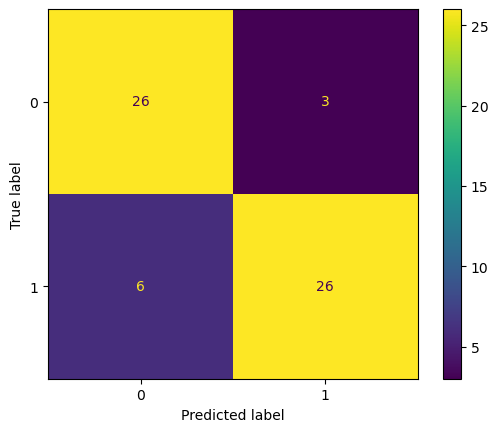

In [15]:
disp.plot()

- The upper-left quadrant displays the number of **true negatives**.
- The bottom-left quadrant displays the number of **false negatives**.
- The upper-right quadrant displays the number of **false positives**.
- The bottom-right quadrant displays the number of **true positives**.

## Metrics

In [19]:
y_pred_proba = lr_model1.predict_proba(x_test)[:, 1]  # Probability scores for class 1

# Calculate metrics
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
roc_auc = metrics.roc_auc_score(y_test, y_pred_proba)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.8525
Precision: 0.8966
Recall: 0.8125
F1-Score: 0.8525
ROC-AUC: 0.9418


These are the results from lr_model1
- Accuracy: 0.8525
- Precision: 0.8966
- Recall: 0.8125
- F1-Score: 0.8525
- ROC-AUC: 0.9418

While the results are good with all scores being higher than 80%, I want to test different 